In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('../Datasets/Iris.csv')

df = df.drop(columns=['Id'])

df['Species'] = df['Species'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
})

In [3]:
X = df.drop(columns=['Species']).values
y = df['Species'].values

print(X.shape, y.shape)

(150, 4) (150,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [6]:
def get_distances(X_train, x):
    distances = []
    
    for x_train in X_train:
        dist = euclidean_distance(x_train, x)
        distances.append(dist)
    
    return np.array(distances)

In [7]:
def get_k_nearest(distances, k):
    return np.argsort(distances)[:k]

In [8]:
def majority_vote(y_train, k_indices):
    k_labels = y_train[k_indices]
    return np.bincount(k_labels).argmax()

In [9]:
def predict_single(X_train, y_train, x, k):
    distances = get_distances(X_train, x)
    k_indices = get_k_nearest(distances, k)
    label = majority_vote(y_train, k_indices)
    return label

In [10]:
def predict(X_train, y_train, X_test, k):
    predictions = []
    
    for x in X_test:
        label = predict_single(X_train, y_train, x, k)
        predictions.append(label)
    
    return np.array(predictions)

In [11]:
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

In [12]:
y_pred = predict(X_train, y_train, X_test, k=3)

acc = accuracy(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


In [16]:
ks = list(range(1, 51, 2))  # odd values only
accuracies = []

for k in ks:
    y_pred = predict(X_train, y_train, X_test, k)
    acc = accuracy(y_test, y_pred)
    accuracies.append(acc)

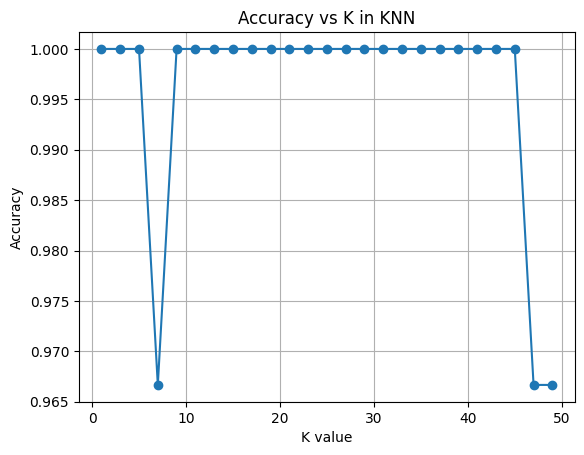

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ks, accuracies, marker='o')

plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K in KNN")

plt.grid()

plt.show()

In [18]:
train_accuracies = []
test_accuracies = []

ks = list(range(1, 51, 2))

for k in ks:
    # Train accuracy
    y_train_pred = predict(X_train, y_train, X_train, k)
    train_acc = accuracy(y_train, y_train_pred)
    train_accuracies.append(train_acc)
    
    # Test accuracy
    y_test_pred = predict(X_train, y_train, X_test, k)
    test_acc = accuracy(y_test, y_test_pred)
    test_accuracies.append(test_acc)

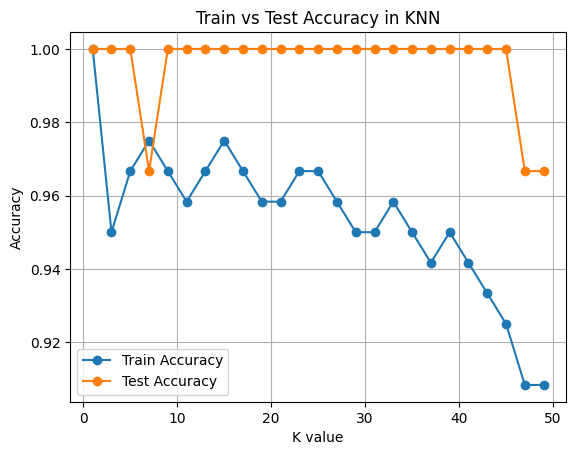

In [19]:
plt.figure()

plt.plot(ks, train_accuracies, label="Train Accuracy", marker='o')
plt.plot(ks, test_accuracies, label="Test Accuracy", marker='o')

plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy in KNN")

plt.legend()
plt.grid()

plt.show()